# Dimensionality Reduction with PCA, t-SNE, and UMAP

This notebook shows how to reduce high-dimensional data to 2D and 3D views with three common methods:

- **PCA**: a fast linear projection that preserves the largest directions of variance;
- **t-SNE**: a nonlinear method that emphasizes local neighborhoods and visible clusters;
- **UMAP**: a nonlinear method that also focuses on neighborhoods, usually runs faster than t-SNE, and can transform new rows after fitting.

Dataset: the `scikit-learn` handwritten digits dataset. Each row is an 8x8 grayscale image flattened into 64 pixel features, with labels from 0 to 9. This is small enough to run locally, but rich enough for the methods to produce visibly different maps.


In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

try:
    import umap
    HAS_UMAP = True
except ImportError:
    umap = None
    HAS_UMAP = False

RANDOM_STATE = 42
N_SAMPLE = 1200

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (8, 4.8),
    "font.size": 11,
})

warnings.filterwarnings(
    "ignore",
    message="The PCA initialization in TSNE will change.*",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message="n_jobs value .* overridden to 1 by setting random_state.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="Auto-removal of grids by pcolor.*",
    category=matplotlib.MatplotlibDeprecationWarning,
)

if not HAS_UMAP:
    print(
        "UMAP is not installed in this Python environment. "
        "Install it with: python -m pip install umap-learn==0.5.6"
    )


/opt/anaconda3/envs/neoversity/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load an Image-Like High-Dimensional Dataset

The digits dataset contains 1,797 small images. Every image has 64 numeric features: one feature for each pixel in an 8x8 grid.

A good dimensionality reduction example should have:

- more than two original features;
- meaningful labels we can color by;
- enough structure that different methods reveal different shapes.


In [2]:
digits = load_digits()

feature_names = [f"pixel_{i:02d}" for i in range(digits.data.shape[1])]
X_full = pd.DataFrame(digits.data, columns=feature_names)
y_full = pd.Series(digits.target, name="digit")
label_names = [str(label) for label in digits.target_names]

summary = pd.DataFrame({
    "rows": [X_full.shape[0]],
    "features": [X_full.shape[1]],
    "classes": [y_full.nunique()],
    "pixel_min": [X_full.to_numpy().min()],
    "pixel_max": [X_full.to_numpy().max()],
})

display(summary)
display(y_full.value_counts().sort_index().rename("count").to_frame().T)
X_full.head()


,rows,features,classes,pixel_min,pixel_max
0,1797,64,10,0.0,16.0


digit,0,1,2,3,4,5,6,7,8,9
count,178,182,177,183,181,182,181,179,174,180


,pixel_00,pixel_01,pixel_02,pixel_03,pixel_04,pixel_05,pixel_06,pixel_07,pixel_08,pixel_09,pixel_10,pixel_11,pixel_12,pixel_13,pixel_14,...,pixel_49,pixel_50,pixel_51,pixel_52,pixel_53,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,...,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,...,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,...,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,...,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,...,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


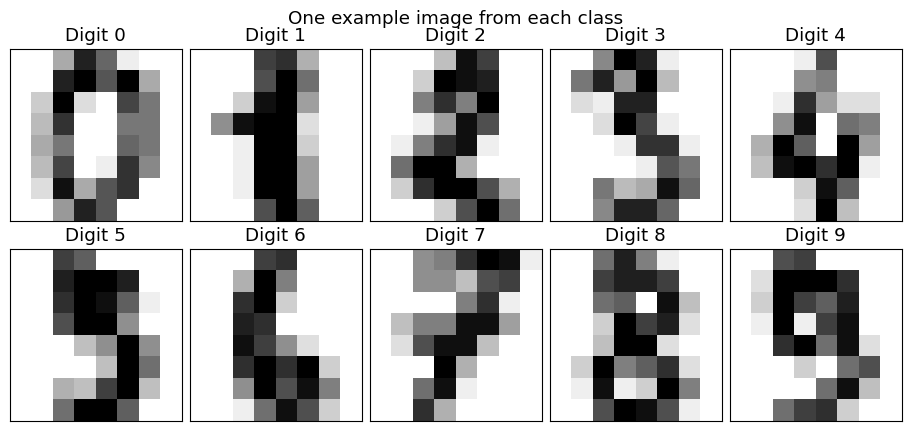

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4), constrained_layout=True)

for digit, ax in zip(range(10), axes.ravel()):
    first_index = np.flatnonzero(y_full.to_numpy() == digit)[0]
    image = digits.images[first_index]
    ax.imshow(image, cmap="gray_r", interpolation="nearest")
    ax.set_title(f"Digit {digit}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("One example image from each class", y=1.04)
plt.show()


## 2. Sample and Scale the Pixel Features

PCA, t-SNE, and UMAP all use distances or variance in feature space. Scaling puts the pixel columns on comparable footing before projection.

The full dataset is already small, but we use a stratified sample of 1,200 rows so t-SNE runs quickly while preserving all digit classes.


In [4]:
splitter = StratifiedShuffleSplit(
    n_splits=1,
    train_size=min(N_SAMPLE, len(X_full)),
    random_state=RANDOM_STATE,
)

sample_index, _ = next(splitter.split(X_full, y_full))
X = X_full.iloc[sample_index].reset_index(drop=True)
y = y_full.iloc[sample_index].reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sample_summary = pd.DataFrame({
    "rows": [X.shape[0]],
    "features": [X.shape[1]],
    "mean_after_scaling": [X_scaled.mean()],
    "std_after_scaling": [X_scaled.std()],
})

display(sample_summary)
display(y.value_counts().sort_index().rename("sample_count").to_frame().T)


,rows,features,mean_after_scaling,std_after_scaling
0,1200,64,3.2844e-18,0.9682


digit,0,1,2,3,4,5,6,7,8,9
sample_count,119,122,118,122,121,122,121,119,116,120


## 3. PCA: Linear Directions of Maximum Variance

Principal Component Analysis rotates the feature space and keeps the axes that explain the most variance. PCA is deterministic, fast, and easy to use as preprocessing before other methods.

The first chart shows how much variance is retained as we add more PCA components. The second chart shows the first few principal components reshaped back into 8x8 pixel grids. Bright and dark regions indicate pixels that move together along each linear direction.


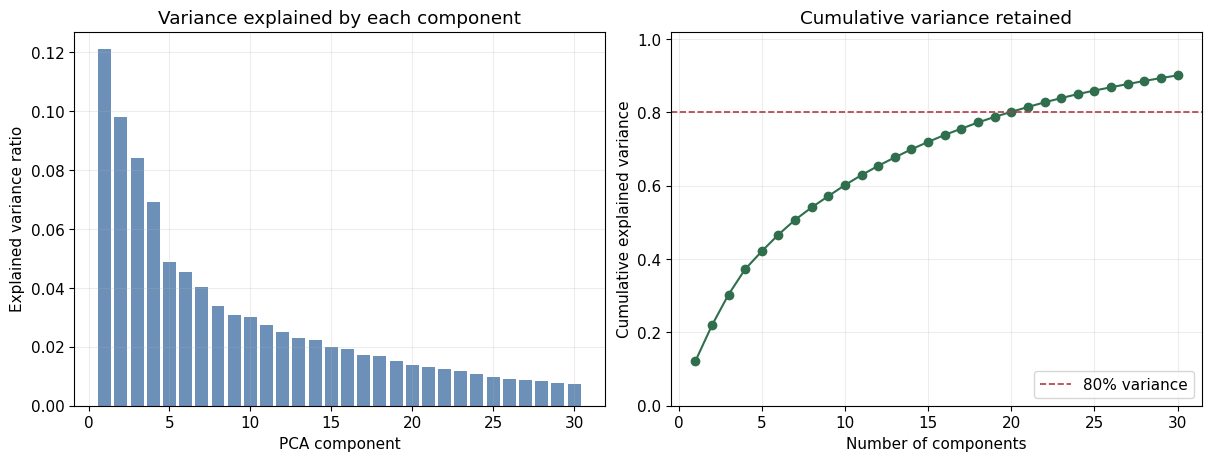

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.1210,0.1210
1,2,0.0981,0.2190
2,3,0.0842,0.3033
3,4,0.0692,0.3724
4,5,0.0488,0.4212
5,6,0.0455,0.4667
6,7,0.0402,0.5069
7,8,0.0340,0.5409
8,9,0.0308,0.5716
9,10,0.0301,0.6018


In [5]:
pca_30 = PCA(n_components=30, random_state=RANDOM_STATE)
X_pca_30 = pca_30.fit_transform(X_scaled)

explained = pd.DataFrame({
    "component": np.arange(1, 31),
    "explained_variance_ratio": pca_30.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_30.explained_variance_ratio_),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].bar(
    explained["component"],
    explained["explained_variance_ratio"],
    color="#4c78a8",
    alpha=0.82,
)
axes[0].set_title("Variance explained by each component")
axes[0].set_xlabel("PCA component")
axes[0].set_ylabel("Explained variance ratio")

axes[1].plot(
    explained["component"],
    explained["cumulative_explained_variance"],
    marker="o",
    color="#2f6f4e",
)
axes[1].axhline(0.80, color="#b23a48", linestyle="--", linewidth=1.2, label="80% variance")
axes[1].set_title("Cumulative variance retained")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="lower right")

plt.show()

display(explained.head(10))


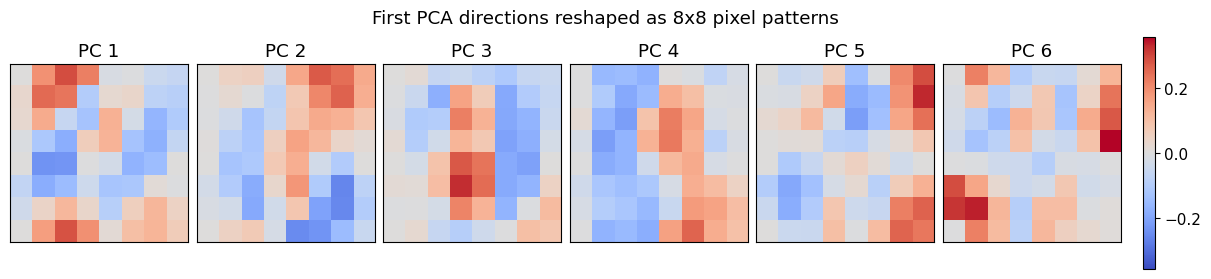

In [6]:
component_count = 6
vmax = np.abs(pca_30.components_[:component_count]).max()

fig, axes = plt.subplots(1, component_count, figsize=(12, 2.4), constrained_layout=True)

for i, ax in enumerate(axes):
    component_image = pca_30.components_[i].reshape(8, 8)
    im = ax.imshow(component_image, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(f"PC {i + 1}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
fig.suptitle("First PCA directions reshaped as 8x8 pixel patterns", y=1.10)
plt.show()


## 4. Build 2D and 3D Embeddings

The helper below times each method and stores its embedding. We compute both 2D and 3D versions so the plotting code is easy to compare.

For t-SNE and UMAP, it is common to first reduce noisy high-dimensional data with PCA. Here we feed the nonlinear methods the first 30 PCA components instead of all 64 scaled pixel columns.


In [7]:
def fit_embedding(method_name, estimator, X_input):
    start = time.perf_counter()
    embedding = estimator.fit_transform(X_input)
    elapsed_seconds = time.perf_counter() - start
    return np.asarray(embedding), elapsed_seconds


def make_tsne(n_components):
    tsne_kwargs = {
        "n_components": n_components,
        "perplexity": 35,
        "learning_rate": 200,
        "init": "pca",
        "random_state": RANDOM_STATE,
    }
    iteration_param = "max_iter" if "max_iter" in TSNE().get_params() else "n_iter"
    tsne_kwargs[iteration_param] = 750
    return TSNE(**tsne_kwargs)


def make_umap(n_components):
    return umap.UMAP(
        n_components=n_components,
        n_neighbors=25,
        min_dist=0.08,
        metric="euclidean",
        random_state=RANDOM_STATE,
    )


In [8]:
embeddings_2d = {}
embeddings_3d = {}
timing_rows = []

# PCA uses the original scaled feature matrix.
for n_components, store in [(2, embeddings_2d), (3, embeddings_3d)]:
    embedding, elapsed = fit_embedding(
        f"PCA {n_components}D",
        PCA(n_components=n_components, random_state=RANDOM_STATE),
        X_scaled,
    )
    store["PCA"] = embedding
    timing_rows.append({"method": "PCA", "dimensions": n_components, "seconds": elapsed})

# t-SNE uses a 30-component PCA preprocessing matrix for speed and denoising.
for n_components, store in [(2, embeddings_2d), (3, embeddings_3d)]:
    embedding, elapsed = fit_embedding(
        f"t-SNE {n_components}D",
        make_tsne(n_components),
        X_pca_30,
    )
    store["t-SNE"] = embedding
    timing_rows.append({"method": "t-SNE", "dimensions": n_components, "seconds": elapsed})

# UMAP requires the optional umap-learn package.
if HAS_UMAP:
    for n_components, store in [(2, embeddings_2d), (3, embeddings_3d)]:
        embedding, elapsed = fit_embedding(
            f"UMAP {n_components}D",
            make_umap(n_components),
            X_pca_30,
        )
        store["UMAP"] = embedding
        timing_rows.append({"method": "UMAP", "dimensions": n_components, "seconds": elapsed})
else:
    print("Skipping UMAP embeddings because umap-learn is not installed.")

runtime = pd.DataFrame(timing_rows)
runtime["seconds"] = runtime["seconds"].round(2)
runtime.sort_values(["dimensions", "method"])


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,method,dimensions,seconds
0,PCA,2,0.00
4,UMAP,2,7.26
2,t-SNE,2,3.24
1,PCA,3,0.01
5,UMAP,3,3.40
3,t-SNE,3,5.51


## 5. Plot 2D Views

Each point is one handwritten digit image. Color shows the true digit label. The axes are learned coordinates, not original features.

What to look for:

- PCA often preserves broad continuous structure, but overlapping classes remain visible;
- t-SNE usually creates tight local islands, which is useful for cluster inspection but can exaggerate separation;
- UMAP often keeps local neighborhoods while leaving more large-scale geometry than t-SNE.


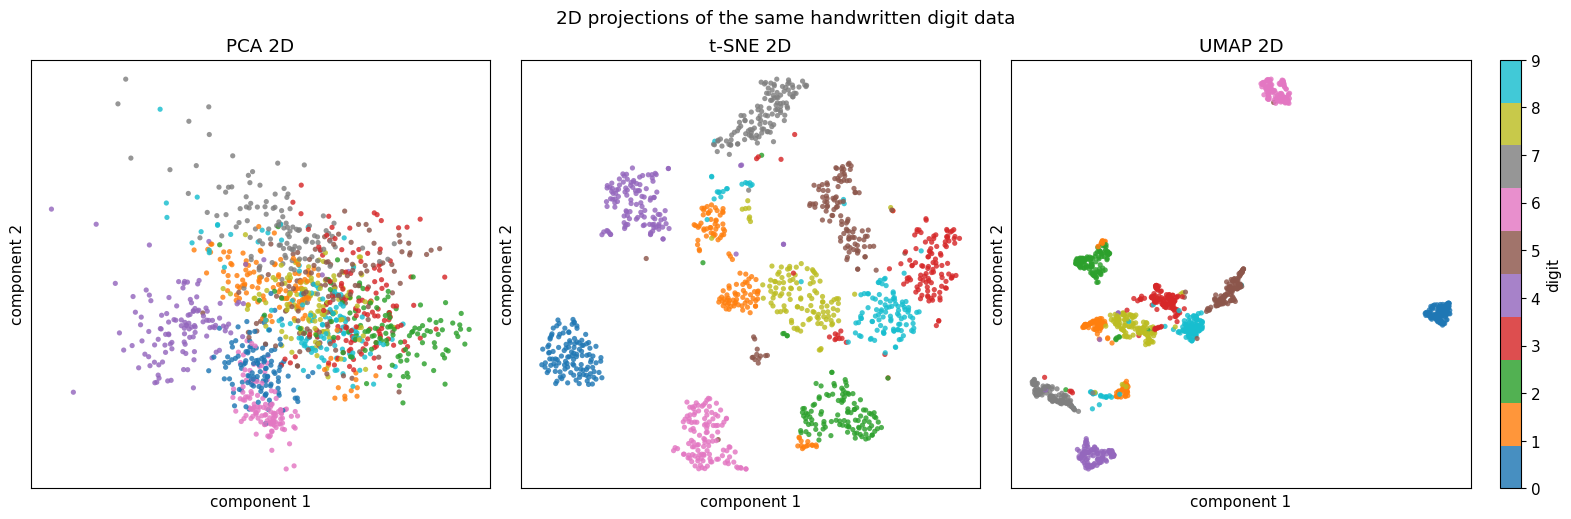

In [9]:
def plot_2d_embeddings(embeddings, labels):
    method_count = len(embeddings)
    fig, axes = plt.subplots(
        1,
        method_count,
        figsize=(5.2 * method_count, 4.8),
        constrained_layout=True,
    )
    if method_count == 1:
        axes = [axes]

    scatter = None
    for ax, (method, embedding) in zip(axes, embeddings.items()):
        scatter = ax.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=labels,
            cmap="tab10",
            s=14,
            alpha=0.82,
            linewidths=0,
        )
        ax.set_title(f"{method} 2D")
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(scatter, ax=axes, ticks=range(10), fraction=0.025, pad=0.02)
    cbar.set_label("digit")
    fig.suptitle("2D projections of the same handwritten digit data", y=1.05)
    plt.show()


plot_2d_embeddings(embeddings_2d, y)


## 6. Plot 3D Views

The 3D versions keep one extra learned coordinate. In a live notebook, rotate the Matplotlib 3D plots to inspect whether groups that overlap in 2D separate in depth.


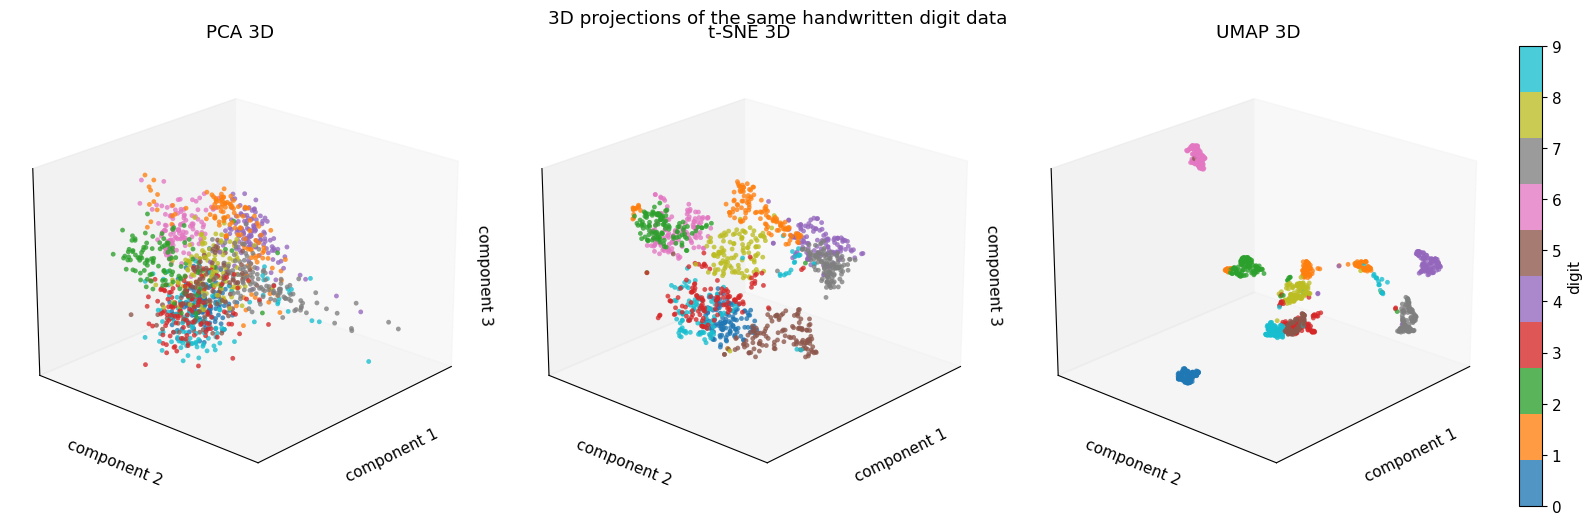

In [10]:
def plot_3d_embeddings(embeddings, labels):
    method_count = len(embeddings)
    fig = plt.figure(figsize=(5.4 * method_count, 5.0), constrained_layout=True)
    axes = []
    scatter = None

    for index, (method, embedding) in enumerate(embeddings.items(), start=1):
        ax = fig.add_subplot(1, method_count, index, projection="3d")
        axes.append(ax)
        scatter = ax.scatter(
            embedding[:, 0],
            embedding[:, 1],
            embedding[:, 2],
            c=labels,
            cmap="tab10",
            s=12,
            alpha=0.78,
            linewidths=0,
        )
        ax.set_title(f"{method} 3D")
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.set_zlabel("component 3")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        ax.view_init(elev=22, azim=42)

    cbar = fig.colorbar(scatter, ax=axes, ticks=range(10), fraction=0.025, pad=0.02)
    cbar.set_label("digit")
    fig.suptitle("3D projections of the same handwritten digit data", y=1.02)
    plt.show()


plot_3d_embeddings(embeddings_3d, y)


## 7. Compare the Methods Quantitatively and Conceptually

Plots are the main teaching tool for dimensionality reduction, but a small metric helps make the tradeoff explicit.

`trustworthiness` measures how well local neighborhoods from the original space are preserved in the embedding. Values closer to 1 are better. It does not measure whether global distances or cluster sizes are faithful.


In [11]:
comparison_rows = []

for dimensions, embedding_dict in [(2, embeddings_2d), (3, embeddings_3d)]:
    for method, embedding in embedding_dict.items():
        row = {
            "method": method,
            "dimensions": dimensions,
            "trustworthiness_k10": trustworthiness(X_scaled, embedding, n_neighbors=10),
        }
        if method == "PCA":
            pca_model = PCA(n_components=dimensions, random_state=RANDOM_STATE).fit(X_scaled)
            row["explained_variance"] = pca_model.explained_variance_ratio_.sum()
        else:
            row["explained_variance"] = np.nan
        comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)
comparison = comparison.merge(runtime, on=["method", "dimensions"], how="left")
comparison = comparison.sort_values(["dimensions", "method"])
comparison["trustworthiness_k10"] = comparison["trustworthiness_k10"].round(4)
comparison["explained_variance"] = comparison["explained_variance"].round(4)
comparison


,method,dimensions,trustworthiness_k10,explained_variance,seconds
0,PCA,2,0.8140,0.2190,0.00
2,UMAP,2,0.9699,NaN,7.26
1,t-SNE,2,0.9839,NaN,3.24
3,PCA,3,0.8988,0.3033,0.01
5,UMAP,3,0.9796,NaN,3.40
4,t-SNE,3,0.9893,NaN,5.51


In [12]:
method_differences = pd.DataFrame([
    {
        "method": "PCA",
        "model_family": "linear projection",
        "best_for": "fast overview, compression, denoising, preprocessing",
        "preserves": "global variance directions",
        "watch_out": "curved clusters can overlap because only linear axes are used",
        "can_transform_new_rows": "yes",
    },
    {
        "method": "t-SNE",
        "model_family": "nonlinear neighborhood embedding",
        "best_for": "visual cluster discovery and local-neighborhood inspection",
        "preserves": "near-neighbor relationships",
        "watch_out": "cluster distances, sizes, and gaps are not reliable measurements",
        "can_transform_new_rows": "not with sklearn TSNE",
    },
    {
        "method": "UMAP",
        "model_family": "nonlinear manifold learning",
        "best_for": "fast visualization, local structure, reusable fitted embeddings",
        "preserves": "local neighborhoods with more global structure than t-SNE in many cases",
        "watch_out": "different n_neighbors and min_dist values can change the map strongly",
        "can_transform_new_rows": "yes, with a fitted umap.UMAP model",
    },
])

method_differences


,method,model_family,best_for,preserves,watch_out,can_transform_new_rows
0,PCA,linear projection,"fast overview, compression, denoising, preproc...",global variance directions,curved clusters can overlap because only linea...,yes
1,t-SNE,nonlinear neighborhood embedding,visual cluster discovery and local-neighborhoo...,near-neighbor relationships,"cluster distances, sizes, and gaps are not rel...",not with sklearn TSNE
2,UMAP,nonlinear manifold learning,"fast visualization, local structure, reusable ...",local neighborhoods with more global structure...,different n_neighbors and min_dist values can ...,"yes, with a fitted umap.UMAP model"


## 8. UMAP Parameter Intuition

UMAP has two especially useful knobs:

- `n_neighbors`: smaller values emphasize very local structure; larger values make the embedding care about broader neighborhoods;
- `min_dist`: smaller values allow tighter clusters; larger values spread points out.

The cell below compares a local UMAP setting with a more global UMAP setting when `umap-learn` is installed.


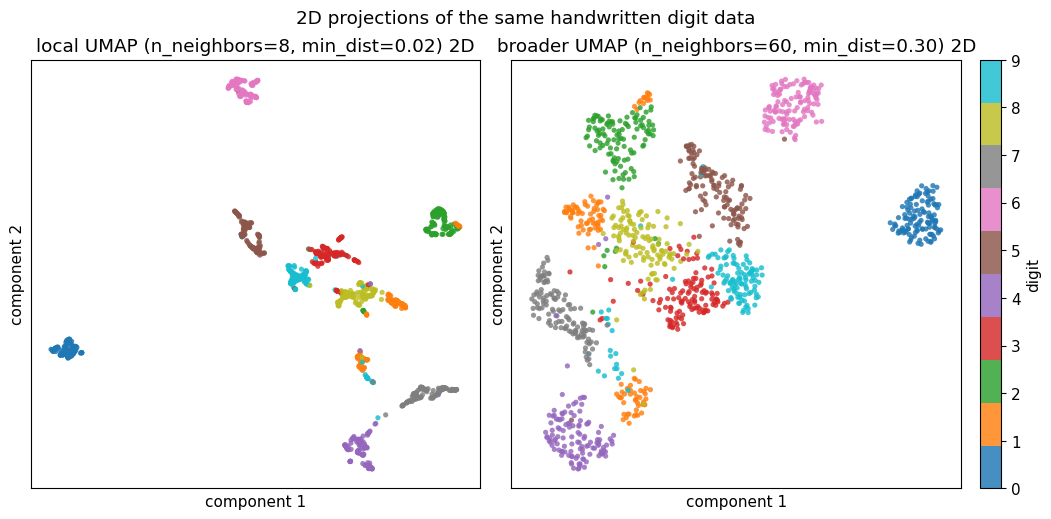

In [13]:
if HAS_UMAP:
    umap_settings = {
        "local UMAP (n_neighbors=8, min_dist=0.02)": umap.UMAP(
            n_components=2,
            n_neighbors=8,
            min_dist=0.02,
            random_state=RANDOM_STATE,
        ),
        "broader UMAP (n_neighbors=60, min_dist=0.30)": umap.UMAP(
            n_components=2,
            n_neighbors=60,
            min_dist=0.30,
            random_state=RANDOM_STATE,
        ),
    }

    setting_embeddings = {}
    for name, estimator in umap_settings.items():
        setting_embeddings[name], _ = fit_embedding(name, estimator, X_pca_30)

    plot_2d_embeddings(setting_embeddings, y)
else:
    print("Install umap-learn to run the UMAP parameter comparison.")


## 9. Practical Takeaways

Use **PCA** first when you need speed, compression, denoising, or a repeatable linear transformation. It is also a good preprocessing step before t-SNE or UMAP.

Use **t-SNE** when the goal is visual inspection of local clusters. Avoid interpreting the exact distance between far-away clusters as a meaningful measurement.

Use **UMAP** when you want a nonlinear visualization that is usually faster than t-SNE, tunable from local to more global structure, and reusable for transforming new rows after fitting.
